In [18]:
import sys
from pathlib import Path

# Add parent directory to path to import lazyfca and utils
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import sklearn.compose
import sklearn.preprocessing
import sklearn.model_selection
import matplotlib.pyplot as plt

from lazyfca import LazyFCA
from utils import estimate_quality

In [19]:
# Load the metric thresholds data
df = pd.read_csv('threshold_results/rice_pr_metric_thresholds.csv')
print(f"Loaded {len(df)} rows")
print(f"Metrics: {df['metric_name'].unique()}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Loaded 100 rows
Metrics: <StringArray>
['lift']
Length: 1, dtype: str

Columns: ['metric_name', 'pos_threshold', 'neg_threshold', 'num_pos_classifiers_passing', 'num_neg_classifiers_passing', 'avg_positive_classifications', 'avg_negative_classifications', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC', 'F1-score', 'True Positive', 'True Negative', 'False Positive', 'False Negative', 'True Negative Rate (Specificity)', 'Negative Predictive Value', 'False Positive Rate', 'False Discovery Rate']


,metric_name,pos_threshold,neg_threshold,num_pos_classifiers_passing,num_neg_classifiers_passing,avg_positive_classifications,avg_negative_classifications,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,lift,1.168712,1.100408,398331,472540,1045.488189,1240.262467,0.921260,0.965035,0.846626,0.981314,0.901961,138,213,5,25,0.977064,0.894958,0.022936,0.034965
1,lift,1.168712,1.172330,398331,449189,1045.488189,1178.973753,0.937008,0.937107,0.914110,0.981257,0.925466,149,208,10,14,0.954128,0.936937,0.045872,0.062893
2,lift,1.168712,1.244252,398331,432708,1045.488189,1135.716535,0.934383,0.925926,0.920245,0.981398,0.923077,150,206,12,13,0.944954,0.940639,0.055046,0.074074
3,lift,1.168712,1.316174,398331,408609,1045.488189,1072.464567,0.921260,0.884393,0.938650,0.981398,0.910714,153,198,20,10,0.908257,0.951923,0.091743,0.115607
4,lift,1.168712,1.388096,398331,389942,1045.488189,1023.469816,0.916010,0.865922,0.950920,0.981553,0.906433,155,194,24,8,0.889908,0.960396,0.110092,0.134078


In [20]:
def plot_threshold_vs_f1(df, metric_name, threshold_type='pos'):
    """
    Plot threshold vs max F1-score for a given metric.
    
    Args:
        df: DataFrame with metric threshold results
        metric_name: Name of the metric to plot
        threshold_type: 'pos' or 'neg' to plot pos_threshold or neg_threshold
    """
    # Filter data for this metric
    metric_df = df[df['metric_name'] == metric_name].copy()
    
    if len(metric_df) == 0:
        print(f"No data found for metric: {metric_name}")
        return
    
    # Group by the threshold of interest and find max F1-score
    if threshold_type == 'pos':
        threshold_col = 'pos_threshold'
        avg_classifications_col = 'avg_positive_classifications'
        other_avg_classifications_col = 'avg_negative_classifications'
        title_label = 'Positive'
    else:
        threshold_col = 'neg_threshold'
        avg_classifications_col = 'avg_negative_classifications'
        other_avg_classifications_col = 'avg_positive_classifications'
        title_label = 'Negative'
    
    # Group by threshold and get max F1-score
    result_rows = []
    for threshold in metric_df[threshold_col].unique():
        subset = metric_df[metric_df[threshold_col] == threshold]
        max_f1_idx = subset['F1-score'].idxmax()
        max_f1_row = subset.loc[max_f1_idx]
        result_rows.append({
            threshold_col: threshold,
            'F1-score': max_f1_row['F1-score'],
            avg_classifications_col: int(max_f1_row[avg_classifications_col]),
            other_avg_classifications_col: int(max_f1_row[other_avg_classifications_col]),
        })
    
    plot_df = pd.DataFrame(result_rows).sort_values(threshold_col)
    
    thresholds = plot_df[threshold_col].values
    f1_scores = plot_df['F1-score'].values
    main_avg_classifications = plot_df[avg_classifications_col].values
    other_avg_classifications = plot_df[other_avg_classifications_col].values
    
    # Create plot
    plt.figure(figsize=(14, 8))
    plt.plot(thresholds, f1_scores, marker='o', linewidth=2, markersize=6, color='blue')
    
    # Add annotations for each point
    for i, (x, y) in enumerate(zip(thresholds, f1_scores)):
        # Main avg classifications (green) above the point
        plt.annotate(f'{main_avg_classifications[i]}', 
                    xy=(x, y), 
                    xytext=(0, 12),
                    textcoords='offset points',
                    ha='center',
                    fontsize=9,
                    color='green',
                    weight='bold')
        
        # Other avg classifications (red) below the point
        plt.annotate(f'{other_avg_classifications[i]}', 
                    xy=(x, y), 
                    xytext=(0, -18),
                    textcoords='offset points',
                    ha='center',
                    fontsize=9,
                    color='red',
                    weight='bold')
    
    plt.xlabel(f'{title_label} Threshold ({metric_name})', fontsize=12)
    plt.ylabel('Max F1 Score', fontsize=12)
    plt.title(f'Max F1 Score vs {title_label} Threshold for {metric_name}\\n(Green = Avg {title_label} Classifications, Red = Avg {"Negative" if threshold_type == "pos" else "Positive"} Classifications)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Show best threshold
    best_idx = np.argmax(f1_scores)
    print(f"\nBest {title_label.lower()} threshold: {thresholds[best_idx]:.6f}")
    print(f"Max F1 score: {f1_scores[best_idx]:.6f}")
    print(f"Avg {title_label.lower()} classifications at best threshold: {main_avg_classifications[best_idx]}")
    print(f"Avg {'negative' if threshold_type == 'pos' else 'positive'} classifications at best threshold: {other_avg_classifications[best_idx]}")
    
    return plot_df

In [21]:
# Get unique metrics in the dataset
metrics = df['metric_name'].unique()
print(f"Available metrics ({len(metrics)}):")
for i, metric in enumerate(metrics, 1):
    print(f"  {i}. {metric}")

Available metrics (1):
  1. lift


Plotting for metric: lift

--- Positive Threshold Analysis ---


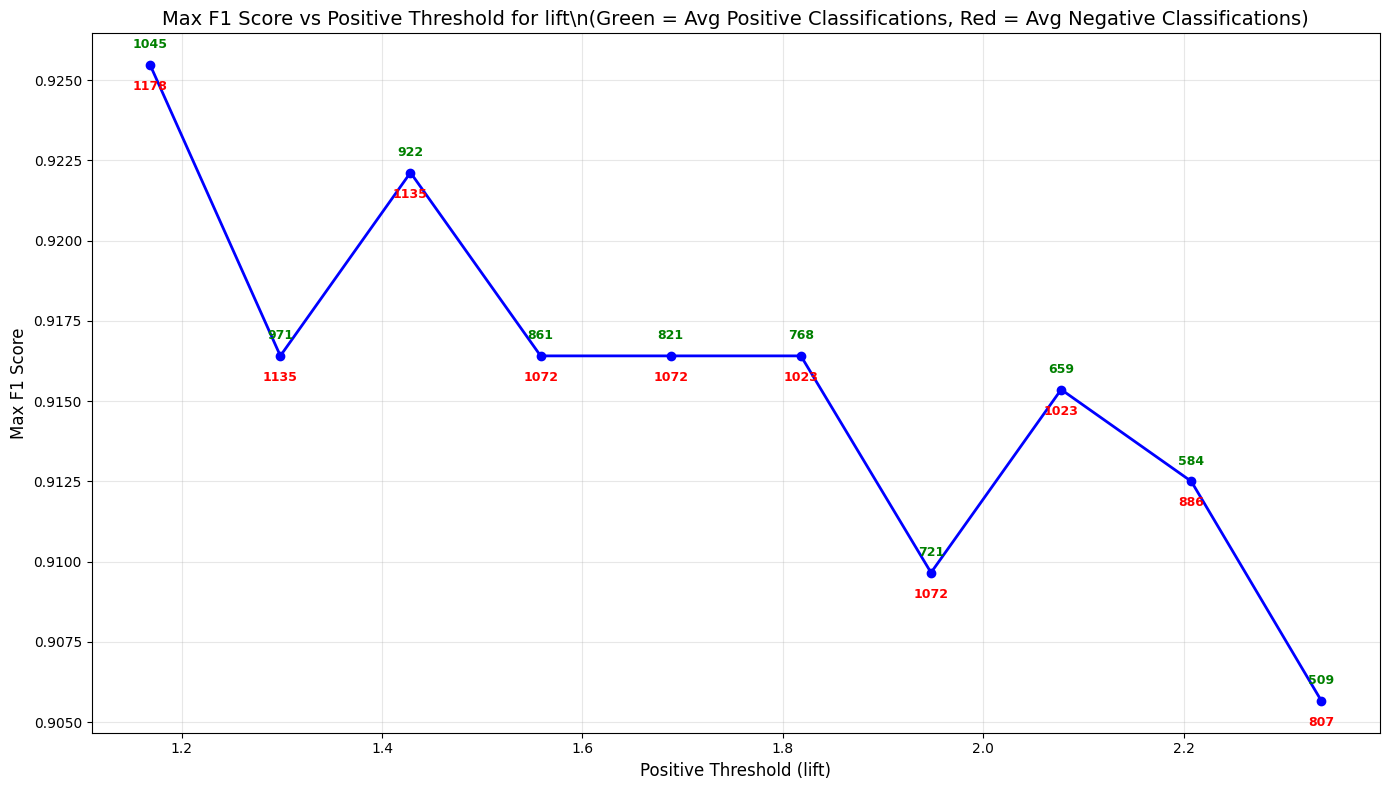


Best positive threshold: 1.168712
Max F1 score: 0.925466
Avg positive classifications at best threshold: 1045
Avg negative classifications at best threshold: 1178

--- Negative Threshold Analysis ---


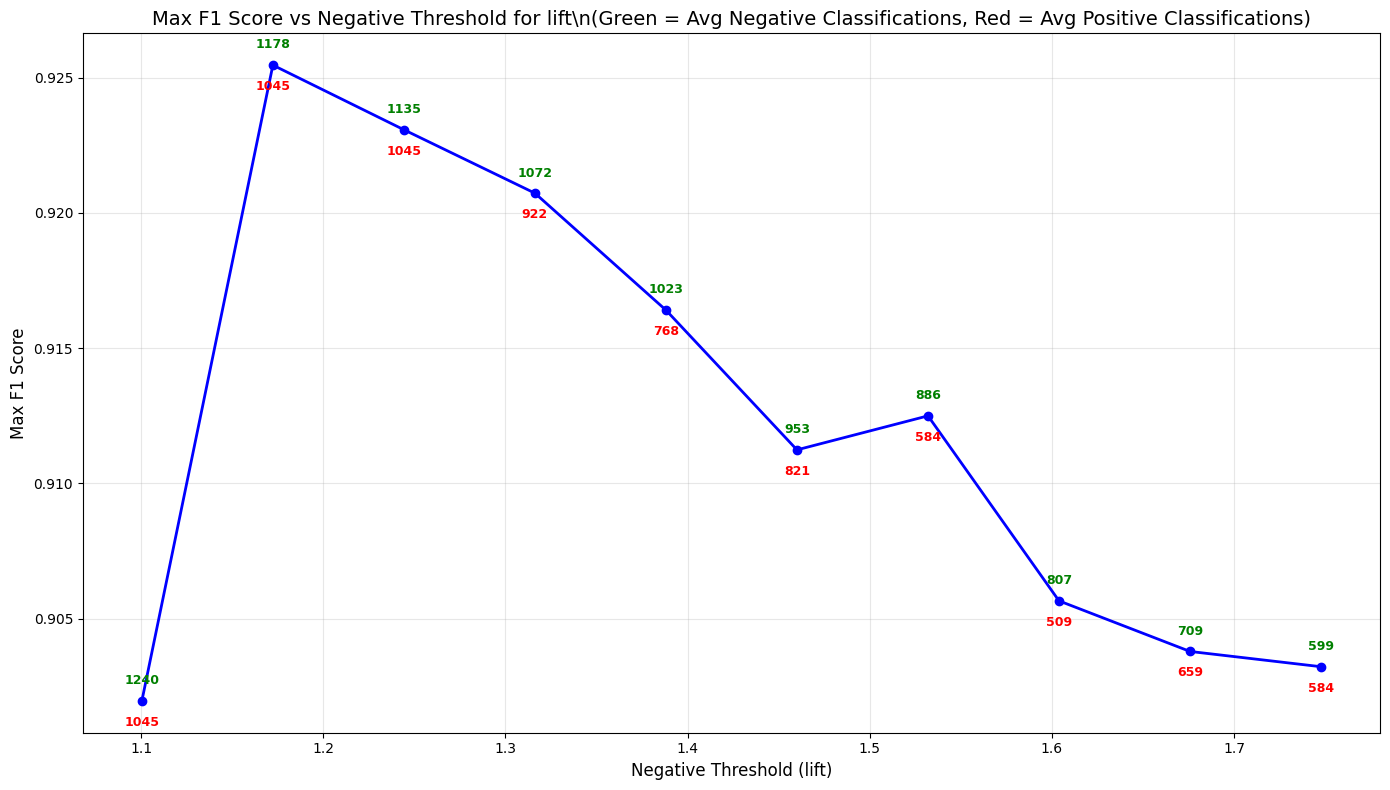


Best negative threshold: 1.172330
Max F1 score: 0.925466
Avg negative classifications at best threshold: 1178
Avg positive classifications at best threshold: 1045


In [22]:
# Example: Plot for the first metric
if len(metrics) > 0:
    example_metric = metrics[0]
    print(f"Plotting for metric: {example_metric}")
    
    # Plot 1: Positive threshold vs Max F1-score
    print("\n--- Positive Threshold Analysis ---")
    plot_threshold_vs_f1(df, example_metric, threshold_type='pos')
    
    # Plot 2: Negative threshold vs Max F1-score
    print("\n--- Negative Threshold Analysis ---")
    plot_threshold_vs_f1(df, example_metric, threshold_type='neg')

In [23]:
# Plot all metrics (uncomment to run for all)
# for metric in metrics:
#     print(f"\n{'='*80}")
#     print(f"Metric: {metric}")
#     print(f"{'='*80}")
#     
#     print("\n--- Positive Threshold Analysis ---")
#     plot_threshold_vs_f1(df, metric, threshold_type='pos')
#     
#     print("\n--- Negative Threshold Analysis ---")
#     plot_threshold_vs_f1(df, metric, threshold_type='neg')

Plotting for metric: lift

--- Positive Threshold Analysis ---


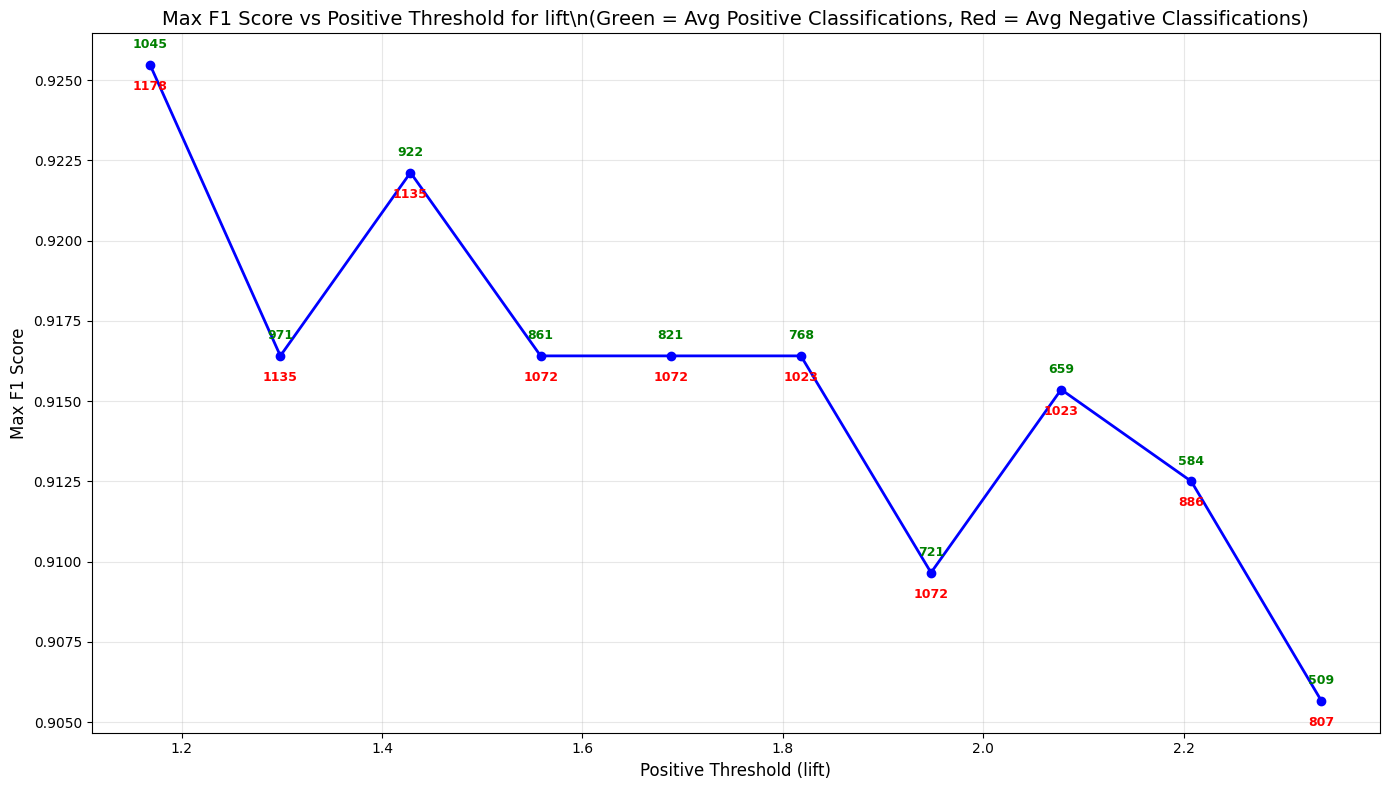


Best positive threshold: 1.168712
Max F1 score: 0.925466
Avg positive classifications at best threshold: 1045
Avg negative classifications at best threshold: 1178

--- Negative Threshold Analysis ---


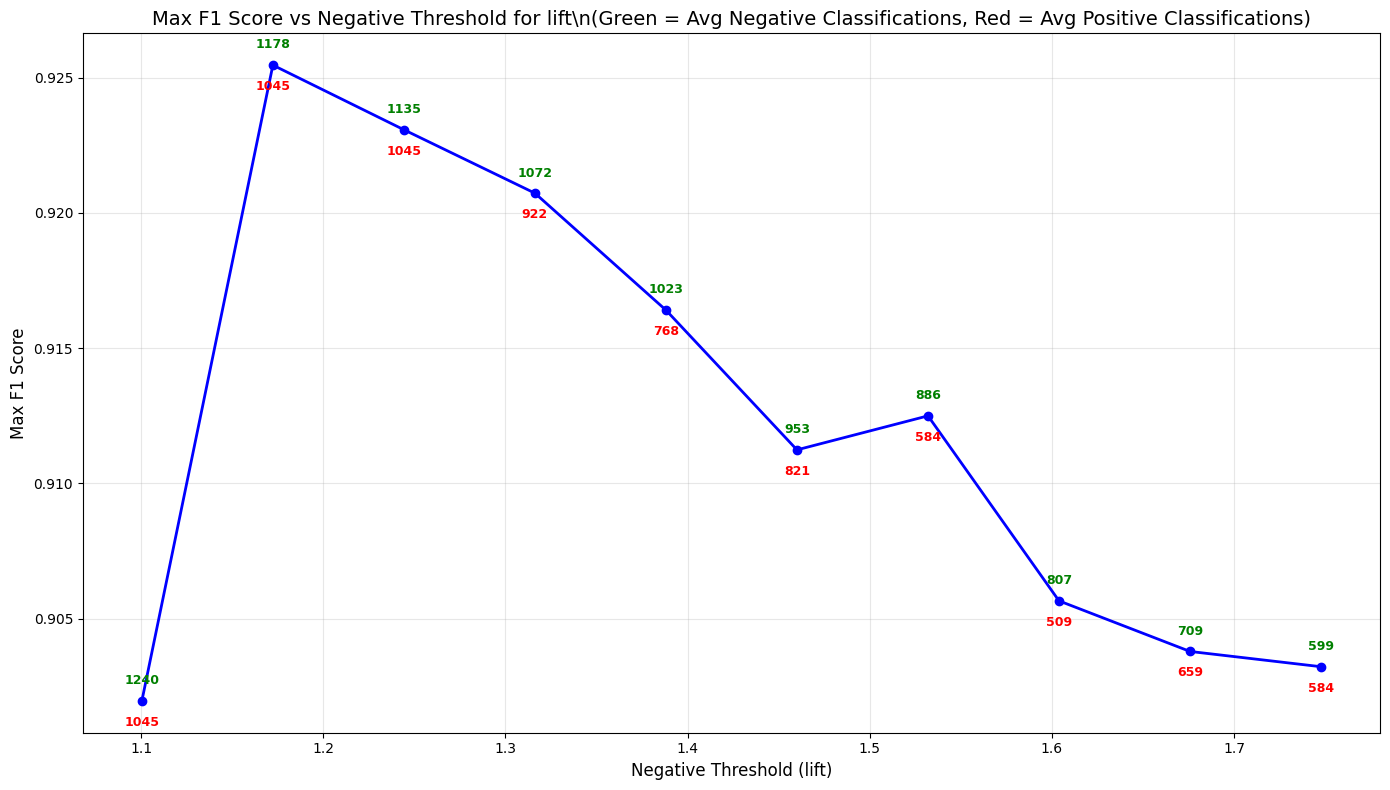


Best negative threshold: 1.172330
Max F1 score: 0.925466
Avg negative classifications at best threshold: 1178
Avg positive classifications at best threshold: 1045


In [24]:
# Plot a specific metric by name
selected_metric = 'lift'  # Change this to any metric from the list above

print(f"Plotting for metric: {selected_metric}")

# Plot 1: Positive threshold vs Max F1-score
print("\n--- Positive Threshold Analysis ---")
pos_results = plot_threshold_vs_f1(df, selected_metric, threshold_type='pos')

# Plot 2: Negative threshold vs Max F1-score
print("\n--- Negative Threshold Analysis ---")
neg_results = plot_threshold_vs_f1(df, selected_metric, threshold_type='neg')

In [25]:
# Summary: Best F1-score for each metric
best_per_metric = []
for metric in df['metric_name'].unique():
    metric_data = df[df['metric_name'] == metric]
    best_row = metric_data.loc[metric_data['F1-score'].idxmax()]
    best_per_metric.append({
        'metric_name': metric,
        'best_f1_score': best_row['F1-score'],
        'best_pos_threshold': best_row['pos_threshold'],
        'best_neg_threshold': best_row['neg_threshold'],
        'avg_pos_classifications': int(best_row['avg_positive_classifications']),
        'avg_neg_classifications': int(best_row['avg_negative_classifications']),
    })

summary_df = pd.DataFrame(best_per_metric).sort_values('best_f1_score', ascending=False)
print("Best F1-score for each metric:\n")
summary_df

Best F1-score for each metric:



,metric_name,best_f1_score,best_pos_threshold,best_neg_threshold,avg_pos_classifications,avg_neg_classifications
0,lift,0.925466,1.168712,1.17233,1045,1178
